# Sesiunea 3/4 - Probabilități, Legea lui Bayes și Naive Bayes

În această sesiune construim treptat ideile necesare pentru a înțelege un clasificator Naive Bayes.

Păstrăm același context ca în sesiunile anterioare: un dataset cu studenți.

Traseul este:

**statistici descriptive -> probabilități -> probabilitate condiționată -> independență -> Bayes -> Naive Bayes**


## Cum lucrezi în notebook

Rulează celulele în ordine.

Pentru exerciții:

1. completează valorile marcate cu `...`;
2. rulează celula;
3. deschide **Hint** doar dacă ai nevoie;
4. deschide **Soluție** dacă ai rămas în urmă.

În Google Colab, salvează o copie personală prin:

`File -> Save a copy in Drive`

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

print("Setup complet!")

Setup complet!


## 2. Încărcarea dataset-ului

Fiecare rând reprezintă un student.

Features numerice:

- `hours_studied`;
- `exercises_solved`;
- `attendance`;
- `previous_score`.

Coloana `test_score` este scorul final.

In [3]:
data_url = (
    "https://raw.githubusercontent.com/"
    "ipworkshop/ipw2026-introduction-to-machine-learning/"
    "main/data/students.csv"
)

df = pd.read_csv(data_url)

df.head()

,student_id,name,hours_studied,exercises_solved,attendance,previous_score,test_score
0,1,Ana,4.5,22,92.0,78.0,85
1,2,Mihai,2.0,11,76.0,64.0,66
2,3,Ioana,5.5,28,96.0,88.0,94
3,4,Andrei,3.0,16,84.0,71.0,76
4,5,Maria,1.5,8,68.0,59.0,57


In [4]:
print("Shape:", df.shape)
print("\nColoane:", df.columns.tolist())
print("\nValori lipsă:")
print(df.isna().sum())

Shape: (30, 7)

Coloane: ['student_id', 'name', 'hours_studied', 'exercises_solved', 'attendance', 'previous_score', 'test_score']

Valori lipsă:
student_id          0
name                0
hours_studied       0
exercises_solved    0
attendance          3
previous_score      2
test_score          0
dtype: int64


## 3. Construirea target-ului de clasificare

Naive Bayes este un algoritm de clasificare.

Transformăm scorul numeric într-o clasă:

- `0` - scor sub `70`;
- `1` - scor de cel puțin `70`.

Pragul este ales didactic. Într-o aplicație reală, el ar proveni din regulile problemei.

In [8]:
PASS_THRESHOLD = 70

df["passed"] = (
    df["test_score"] >= PASS_THRESHOLD
).astype(int)

df[["name", "test_score", "passed"]].head(10)

,name,test_score,passed
0,Ana,85,1
1,Mihai,66,0
2,Ioana,94,1
3,Andrei,76,1
4,Maria,57,0
5,Vlad,97,1
6,Elena,80,1
7,Radu,70,1
8,Sofia,86,1
9,Alex,51,0


In [9]:
print(df["passed"].value_counts().sort_index())
print()
print(df["passed"].value_counts(normalize=True).sort_index())

passed
0     9
1    21
Name: count, dtype: int64

passed
0    0.3
1    0.7
Name: proportion, dtype: float64


# Partea I - Statistică descriptivă

## 4. Media

Media descrie valoarea centrală aproximativă a unui set de numere.

În dataset-ul nostru, putem calcula media pentru orice coloană numerică, de exemplu:

- media orelor studiate de toți studenții;
- media numărului de exerciții rezolvate;
- media prezenței;
- media scorurilor anterioare;
- media scorurilor finale.

Pentru un set de valori:

$$
x_1, x_2, \ldots, x_n
$$

media se calculează astfel:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

Unde:

- $x_i$ reprezintă fiecare valoare din set;
- $n$ reprezintă numărul total de valori;
- $\bar{x}$ reprezintă media.

Pașii sunt:

1. adunăm toate valorile;
2. numărăm câte valori avem;
3. împărțim suma la numărul de valori.

De exemplu, pentru scorurile:

`[60, 70, 80, 90]`

calculul este:

$$
\bar{x} = \frac{60 + 70 + 80 + 90}{4} = 75
$$

Așadar, scorul mediu este `75`.

În cod, vom calcula media atât manual, folosind suma și numărul valorilor, cât și prin metoda NumPy `.mean()`.

In [5]:
scores = np.array([60, 70, 80, 90])

manual_mean = scores.sum() / len(scores)
numpy_mean = scores.mean()

print("Calcul manual:", manual_mean)
print("NumPy:", numpy_mean)

Calcul manual: 75.0
NumPy: 75.0


### Compararea mediilor dintre clase

Până acum am calculat media pentru un singur set de valori.

În continuare vrem să comparăm două grupe de studenți:

- studenții din clasa `0`, care au un scor sub pragul ales;
- studenții din clasa `1`, care au un scor cel puțin egal cu pragul ales.

Întrebarea noastră este:

> Studenții din cele două clase diferă din punctul de vedere al orelor studiate și al scorului anterior?

Pentru a răspunde, calculăm separat:

- media orelor studiate pentru clasa `0`;
- media orelor studiate pentru clasa `1`;
- media scorului anterior pentru clasa `0`;
- media scorului anterior pentru clasa `1`.

Mai întâi putem separa manual cele două grupe folosind filtrarea Pandas.

In [10]:
class_0_students = df[df["passed"] == 0]
class_1_students = df[df["passed"] == 1]

class_0_hours_mean = class_0_students["hours_studied"].mean()
class_1_hours_mean = class_1_students["hours_studied"].mean()

print("Media orelor pentru clasa 0:", class_0_hours_mean)
print("Media orelor pentru clasa 1:", class_1_hours_mean)

Media orelor pentru clasa 0: 1.5555555555555556
Media orelor pentru clasa 1: 4.119047619047619


### Task 1 - Compararea mediilor dintre clase

Separă studenții în două grupe:

- `class_0_students` pentru studenții cu `passed == 0`;
- `class_1_students` pentru studenții cu `passed == 1`.

Pentru fiecare grupă, calculează:

- media coloanei `hours_studied`;
- media coloanei `previous_score`.

Salvează rezultatele în:

- `class_0_hours_mean`;
- `class_1_hours_mean`;
- `class_0_previous_score_mean`;
- `class_1_previous_score_mean`.

La final, compară valorile.

Întrebări pentru interpretare:

- Care clasă a studiat mai multe ore în medie?
- Care clasă avea un scor anterior mai mare în medie?

In [ ]:
class_0_students = ...
class_1_students = ...

class_0_hours_mean = ...
class_1_hours_mean = ...

class_0_previous_score_mean = ...
class_1_previous_score_mean = ...

print("Clasa 0 - media orelor:", class_0_hours_mean)
print("Clasa 1 - media orelor:", class_1_hours_mean)

print(
    "Clasa 0 - media scorului anterior:",
    class_0_previous_score_mean,
)

print(
    "Clasa 1 - media scorului anterior:",
    class_1_previous_score_mean,
)

<details>
<summary><strong>Hint</strong></summary>

Pentru a selecta studenții dintr-o clasă, folosește filtrarea Pandas:

`df[df["passed"] == valoarea_clasei]`

După ce ai separat grupele, selectează coloana dorită și aplică `.mean()`.

De exemplu:

`class_0_students["hours_studied"].mean()`

</details>

<details>
<summary><strong>Soluție</strong></summary>

```python
class_0_students = df[df["passed"] == 0]
class_1_students = df[df["passed"] == 1]

class_0_hours_mean = class_0_students[
    "hours_studied"
].mean()

class_1_hours_mean = class_1_students[
    "hours_studied"
].mean()

class_0_previous_score_mean = class_0_students[
    "previous_score"
].mean()

class_1_previous_score_mean = class_1_students[
    "previous_score"
].mean()

## 5. Varianța

Media ne spune unde se află centrul aproximativ al valorilor, dar nu ne spune cât de apropiate sau cât de împrăștiate sunt valorile în jurul acelui centru.

Două seturi pot avea aceeași medie, dar distribuții foarte diferite.

De exemplu:

- grupa A: `[69, 70, 71]`;
- grupa B: `[40, 70, 100]`.

Ambele grupe au media `70`.

Totuși:

- valorile din grupa A sunt foarte apropiate de medie;
- valorile din grupa B sunt mult mai îndepărtate de medie.

Varianța măsoară această împrăștiere.

O varianță mică înseamnă că valorile sunt, în general, apropiate de medie.

O varianță mare înseamnă că valorile sunt mai răspândite și pot fi la distanțe mai mari față de medie.

Pentru un set de valori:

$$
x_1, x_2, \ldots, x_n
$$

varianța se calculează astfel:

$$
Var(X) =
\frac{1}{n}
\sum_{i=1}^{n}
(x_i - \bar{x})^2
$$

Unde:

- $x_i$ reprezintă fiecare valoare din set;
- $\bar{x}$ reprezintă media valorilor;
- $x_i - \bar{x}$ reprezintă distanța unei valori față de medie;
- $n$ reprezintă numărul total de valori;
- $Var(X)$ reprezintă varianța.

Pașii sunt:

1. calculăm media valorilor;
2. scădem media din fiecare valoare;
3. ridicăm fiecare diferență la pătrat;
4. adunăm diferențele ridicate la pătrat;
5. împărțim suma la numărul de valori.

### Exemplu

Pentru valorile:

`[60, 70, 80, 90]`

media este:

$$
\bar{x} =
\frac{60 + 70 + 80 + 90}{4}
= 75
$$

Diferențele față de medie sunt:

$$
60 - 75 = -15
$$

$$
70 - 75 = -5
$$

$$
80 - 75 = 5
$$

$$
90 - 75 = 15
$$

Ridicăm diferențele la pătrat:

$$
(-15)^2 = 225
$$

$$
(-5)^2 = 25
$$

$$
5^2 = 25
$$

$$
15^2 = 225
$$

Calculăm media acestor valori:

$$
Var(X) =
\frac{225 + 25 + 25 + 225}{4}
= 125
$$

Varianța setului este `125`.

Ridicăm diferențele la pătrat din două motive:

- diferențele negative și pozitive nu se mai anulează;
- valorile aflate foarte departe de medie contribuie mai mult la rezultat.

În dataset-ul nostru putem calcula, de exemplu:

- varianța orelor studiate;
- varianța scorurilor anterioare;
- varianța scorurilor finale;
- varianța fiecărui feature separat pentru clasele `0` și `1`.


In [11]:
values = np.array([60, 70, 80, 90])

mean_value = values.mean()
deviations = values - mean_value
squared_deviations = deviations ** 2
manual_variance = squared_deviations.mean()

print("Media:", mean_value)
print("Diferențe:", deviations)
print("Diferențe la pătrat:", squared_deviations)
print("Varianță:", manual_variance)

Media: 75.0
Diferențe: [-15.  -5.   5.  15.]
Diferențe la pătrat: [225.  25.  25. 225.]
Varianță: 125.0


## 6. Deviația standard

Varianța ne arată cât de împrăștiate sunt valorile în jurul mediei, dar rezultatul ei este exprimat în unități ridicate la pătrat.

De exemplu, dacă analizăm scoruri măsurate în puncte:

- scorurile sunt exprimate în puncte;
- diferențele față de medie sunt exprimate tot în puncte;
- după ridicarea diferențelor la pătrat, varianța este exprimată în puncte la pătrat.

Din acest motiv, valoarea varianței nu este întotdeauna ușor de interpretat direct.

Deviația standard rezolvă această problemă prin aplicarea rădăcinii pătrate asupra varianței:

$$
\sigma = \sqrt{Var(X)}
$$

Unde:

- $Var(X)$ reprezintă varianța;
- $\sigma$ reprezintă deviația standard.

Prin rădăcina pătrată, rezultatul revine la aceeași unitate ca datele originale.

### Exemplu

Pentru setul:

`[60, 70, 80, 90]`

am calculat anterior varianța:

$$
Var(X) = 125
$$

Deviația standard este:

$$
\sigma = \sqrt{125} \approx 11.18
$$

Scorurile sunt măsurate în puncte, deci deviația standard este de aproximativ `11.18` puncte.

Putem interpreta intuitiv acest rezultat astfel:

> Scorurile se află, în general, la aproximativ `11.18` puncte distanță față de media de `75`.

Aceasta este o interpretare orientativă. Deviația standard nu înseamnă că fiecare valoare se află exact la această distanță față de medie.

### Interpretarea valorii

O deviație standard mică înseamnă că valorile sunt grupate mai aproape de medie.

O deviație standard mare înseamnă că valorile sunt mai răspândite.

De exemplu:

- grupa A: `[69, 70, 71]`;
- grupa B: `[40, 70, 100]`.

Ambele au media `70`, dar:

- grupa A are o deviație standard mică;
- grupa B are o deviație standard mare.

Prin urmare, media ne spune unde se află centrul datelor, iar deviația standard ne spune cât de mult se abat valorile de la acel centru.

În dataset-ul nostru putem calcula, de exemplu:

- deviația standard a orelor studiate;
- deviația standard a scorurilor anterioare;
- deviația standard a scorurilor finale;
- deviația standard a fiecărui feature separat pentru clasele `0` și `1`.


In [12]:
standard_deviation = np.sqrt(manual_variance)
numpy_standard_deviation = values.std()

print(
    "Deviația standard calculată din varianță:",
    standard_deviation,
)

print(
    "Deviația standard calculată cu NumPy:",
    numpy_standard_deviation,
)

Deviația standard calculată din varianță: 11.180339887498949
Deviația standard calculată cu NumPy: 11.180339887498949


### Task 2 - Media, varianța și deviația standard a scorurilor finale

În acest exercițiu analizăm coloana `test_score`, care conține scorul final obținut de fiecare student.

Vrem să calculăm trei statistici:

1. **media**, care ne spune care este scorul central aproximativ;
2. **varianța**, care ne spune cât de împrăștiate sunt scorurile în jurul mediei;
3. **deviația standard**, care exprimă aceeași dispersie într-o unitate mai ușor de interpretat: puncte.

Completează:

- `score_mean` cu media coloanei `test_score`;
- `score_variance` cu varianța coloanei `test_score`;
- `score_std` cu deviația standard a coloanei `test_score`.

După ce rulezi celula, interpretează rezultatele:

- Care este scorul mediu?
- Scorurile par apropiate sau împrăștiate în jurul mediei?
- La aproximativ câte puncte față de medie se află, în general, scorurile?

In [ ]:
score_mean = ...
score_variance = ...
score_std = ...

print("Media scorurilor finale:", score_mean)
print("Varianța scorurilor finale:", score_variance)
print("Deviația standard a scorurilor finale:", score_std)

<details>
<summary><strong>Hint</strong></summary>

Lucrează cu coloana:

`df["test_score"]`

Folosește:

- `.mean()` pentru medie;
- `.var()` pentru varianță;
- `.std()` pentru deviația standard.

</details>

<details>
<summary><strong>Soluție</strong></summary>

```python
score_mean = df["test_score"].mean()
score_variance = df["test_score"].var()
score_std = df["test_score"].std()

print("Media scorurilor finale:", score_mean)
print("Varianța scorurilor finale:", score_variance)
print("Deviația standard a scorurilor finale:", score_std)

## 7. Covarianța

Covarianța măsoară modul în care două variabile tind să se modifice împreună.

În dataset-ul nostru putem analiza, de exemplu:

- dacă numărul de ore studiate crește împreună cu scorul final;
- dacă numărul de exerciții rezolvate crește împreună cu scorul final;
- dacă prezența și scorul anterior tind să varieze în aceeași direcție.

Pentru două variabile $X$ și $Y$, covarianța poate fi scrisă astfel:

$$
Cov(X, Y) =
\frac{1}{n}
\sum_{i=1}^{n}
(x_i - \bar{x})
(y_i - \bar{y})
$$

Unde:

- $x_i$ reprezintă o valoare din prima variabilă;
- $y_i$ reprezintă valoarea corespunzătoare din a doua variabilă;
- $\bar{x}$ este media primei variabile;
- $\bar{y}$ este media celei de-a doua variabile;
- $n$ este numărul de observații.

Intuitiv, pentru fiecare student analizăm:

- dacă valoarea lui pentru $X$ este peste sau sub media lui $X$;
- dacă valoarea lui pentru $Y$ este peste sau sub media lui $Y$.

Apoi înmulțim cele două diferențe.

### Cum interpretăm semnul

#### Covarianță pozitivă

Dacă ambele valori tind să fie simultan peste medie sau simultan sub medie, produsul diferențelor este pozitiv.

Asta sugerează că variabilele tind să crească sau să scadă împreună.

De exemplu:

- mai multe ore studiate;
- scor final mai mare.

#### Covarianță negativă

Dacă una dintre valori este peste medie, iar cealaltă este sub medie, produsul diferențelor este negativ.

Asta sugerează că una dintre variabile tinde să crească atunci când cealaltă scade.

#### Covarianță apropiată de zero

O valoare apropiată de zero sugerează că nu observăm o relație liniară clară între cele două variabile.

Totuși, asta nu înseamnă neapărat că variabilele sunt complet independente. Poate exista o relație mai complexă, neliniară.

### De ce interpretarea valorii este dificilă

Mărimea covarianței depinde de unitățile și scara variabilelor.

De exemplu:

- `hours_studied` este măsurat în ore;
- `test_score` este măsurat în puncte;
- `attendance` este măsurată în procente.

Din acest motiv, o covarianță de `20` nu poate fi interpretată singură ca fiind „mare” sau „mică”.

Semnul este ușor de interpretat, dar mărimea nu este standardizată.

Pentru o interpretare mai ușoară a intensității relației vom folosi apoi corelația.

In [13]:
hours_test_covariance = df[
    ["hours_studied", "test_score"]
].cov()

hours_test_covariance

,hours_studied,test_score
hours_studied,2.450862,22.298276
test_score,22.298276,210.378161


Rezultatul este o matrice de covarianță.

Pozițiile de pe diagonală reprezintă varianța fiecărei coloane:

- `Cov(hours_studied, hours_studied)` este varianța orelor studiate;
- `Cov(test_score, test_score)` este varianța scorurilor finale.

Valorile din afara diagonalei reprezintă covarianța dintre cele două variabile.

Matricea este simetrică:

`Cov(X, Y) = Cov(Y, X)`

In [14]:
numeric_columns = [
    "hours_studied",
    "exercises_solved",
    "attendance",
    "previous_score",
    "test_score",
]

covariance_matrix = df[numeric_columns].cov()

covariance_matrix

,hours_studied,exercises_solved,attendance,previous_score,test_score
hours_studied,2.450862,12.403448,18.397436,18.783069,22.298276
exercises_solved,12.403448,63.213793,92.564103,95.215608,112.979310
attendance,18.397436,92.564103,133.000000,143.496667,173.294872
previous_score,18.783069,95.215608,143.496667,143.294974,174.071429
test_score,22.298276,112.979310,173.294872,174.071429,210.378161


## 8. Corelația

Covarianța ne arată dacă două variabile tind să se modifice în aceeași direcție sau în direcții opuse.

Problema este că valoarea covarianței depinde de unitățile de măsură și de scara variabilelor.

De exemplu:

- `hours_studied` este măsurat în ore;
- `attendance` este măsurată în procente;
- `test_score` este măsurat în puncte.

Din acest motiv, o covarianță de `20` nu ne spune singură dacă relația este puternică sau slabă.

Corelația rezolvă această problemă prin standardizarea covarianței.

Pentru două variabile $X$ și $Y$, coeficientul de corelație poate fi scris astfel:

$$
Corr(X, Y) =
\frac{Cov(X, Y)}
{\sigma_X \sigma_Y}
$$

Unde:

- $Cov(X, Y)$ este covarianța dintre cele două variabile;
- $\sigma_X$ este deviația standard a lui $X$;
- $\sigma_Y$ este deviația standard a lui $Y$.

Împărțirea la deviațiile standard elimină efectul unităților de măsură.

Din acest motiv, corelația este întotdeauna între `-1` și `1`.

### Cum interpretăm corelația

#### Corelație pozitivă

O valoare pozitivă înseamnă că variabilele tind să crească împreună.

De exemplu:

- mai multe ore studiate;
- scor final mai mare.

Cu cât valoarea este mai aproape de `1`, cu atât relația liniară pozitivă este mai puternică.

#### Corelație negativă

O valoare negativă înseamnă că una dintre variabile tinde să crească atunci când cealaltă scade.

Cu cât valoarea este mai aproape de `-1`, cu atât relația liniară negativă este mai puternică.

#### Corelație apropiată de zero

O valoare apropiată de `0` înseamnă că nu observăm o relație liniară clară.

Asta nu înseamnă neapărat că variabilele nu au nicio legătură.

Poate exista o relație neliniară pe care corelația nu o surprinde.

### Corelația nu implică automat cauzalitate

Dacă două variabile sunt corelate, nu înseamnă automat că una o cauzează pe cealaltă.

De exemplu, orele studiate și scorul final pot fi corelate, dar rezultatul poate fi influențat și de:

- nivelul anterior de pregătire;
- dificultatea testului;
- prezență;
- experiență;
- factori pe care nu îi avem în dataset.

Corelația ne spune că există o asociere liniară, nu dovedește o relație cauzală.

In [15]:
hours_score_correlation = df[
    ["hours_studied", "test_score"]
].corr()

hours_score_correlation

,hours_studied,test_score
hours_studied,1.000,0.982
test_score,0.982,1.000


Rezultatul este o matrice de corelație.

Valorile de pe diagonală sunt `1`, deoarece fiecare variabilă este perfect corelată cu ea însăși.

Valorile din afara diagonalei reprezintă corelația dintre cele două variabile.

Matricea este simetrică:

`Corr(X, Y) = Corr(Y, X)`

In [16]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,hours_studied,exercises_solved,attendance,previous_score,test_score
hours_studied,1.000000,0.996499,0.973648,0.989251,0.982000
exercises_solved,0.996499,1.000000,0.968097,0.989098,0.979699
attendance,0.973648,0.968097,1.000000,0.984182,0.995171
previous_score,0.989251,0.989098,0.984182,1.000000,0.993196
test_score,0.982000,0.979699,0.995171,0.993196,1.000000


### Vizualizarea relației

Corelația oferă un singur număr.

Scatter plot-ul ne ajută să vedem cum sunt distribuite efectiv observațiile.

Fiecare punct reprezintă un student:

- poziția pe axa X este numărul de ore studiate;
- poziția pe axa Y este scorul final.

Dacă punctele formează aproximativ o direcție ascendentă, relația este pozitivă.

Dacă punctele formează o direcție descendentă, relația este negativă.

Dacă punctele sunt foarte împrăștiate fără o direcție clară, relația liniară este slabă.

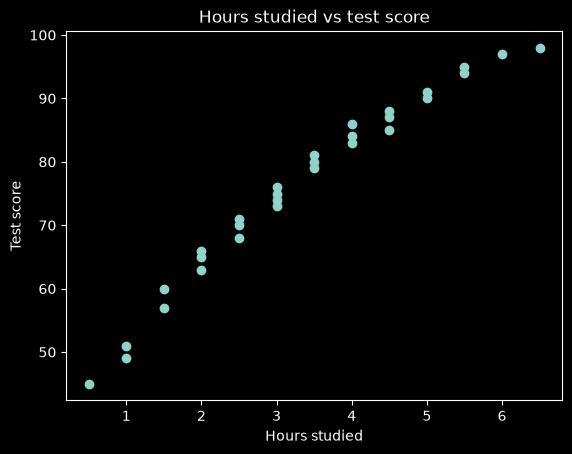

In [17]:
plt.scatter(
    df["hours_studied"],
    df["test_score"],
)

plt.xlabel("Hours studied")
plt.ylabel("Test score")
plt.title("Hours studied vs test score")
plt.show()

### Task 3 - Relația dintre exercițiile rezolvate și scorul final

În acest exercițiu analizăm legătura dintre:

- `exercises_solved` - numărul de exerciții rezolvate;
- `test_score` - scorul final obținut.

Vrem să calculăm două valori:

1. **covarianța**, care ne arată direcția în care tind să varieze cele două variabile;
2. **corelația**, care ne arată atât direcția, cât și intensitatea relației liniare, pe o scară între `-1` și `1`.

Mai întâi selectăm cele două coloane și le salvăm în `selected`.

Apoi:

- calculează matricea de covarianță;
- extrage valoarea din afara diagonalei;
- calculează matricea de corelație;
- extrage valoarea din afara diagonalei.

Salvează rezultatele în:

- `exercise_score_covariance`;
- `exercise_score_correlation`.

După rulare, încearcă să răspunzi:

- Semnul covarianței este pozitiv sau negativ?
- Corelația indică o relație slabă, moderată sau puternică?
- Rezultatul susține ideea că mai multe exerciții rezolvate sunt asociate cu un scor final mai mare?

In [ ]:
selected = df[[
    "exercises_solved",
    "test_score",
]]

exercise_score_covariance = ...
exercise_score_correlation = ...

print("Covarianță:", exercise_score_covariance)
print("Corelație:", exercise_score_correlation)

<details>
<summary><strong>Hint</strong></summary>

`selected.cov()` întoarce o matrice de forma:

`2 × 2`

Pozițiile de pe diagonală conțin varianțele fiecărei coloane.

Valorile din afara diagonalei conțin covarianța dintre cele două coloane.

Pentru că matricea este simetrică, putem selecta valoarea de pe poziția:

`[0, 1]`

În Pandas, folosim:

`selected.cov().iloc[0, 1]`

Pentru corelație facem același lucru cu:

`selected.corr().iloc[0, 1]`

</details>

<details>
<summary><strong>Soluție</strong></summary>

```python
covariance_matrix = selected.cov()
correlation_matrix = selected.corr()

exercise_score_covariance = covariance_matrix.iloc[0, 1]
exercise_score_correlation = correlation_matrix.iloc[0, 1]

print("Covarianță:", exercise_score_covariance)
print("Corelație:", exercise_score_correlation)

# Partea a II-a - Probabilități

## 9. Evenimente și probabilitate

Un eveniment este o afirmație care poate fi adevărată sau falsă.

Exemple:

- studentul are `passed = 1`;
- studentul a studiat cel puțin 4 ore;
- studentul are prezență de cel puțin 80%.

Estimăm probabilitatea prin frecvență:

$$
P(A)=\frac{\text{cazuri favorabile}}{\text{numărul total de cazuri}}
$$

In [18]:
passed_event = df["passed"] == 1
p_passed = passed_event.mean()

print("P(passed):", p_passed)

P(passed): 0.7


Media funcționează deoarece:

- `True` este tratat ca `1`;
- `False` este tratat ca `0`.

Media unui vector boolean este proporția valorilor `True`.

In [19]:
studied_enough_event = df["hours_studied"] >= 4

print(
    "P(hours_studied >= 4):",
    studied_enough_event.mean(),
)

P(hours_studied >= 4): 0.4


### Task 4 - Probabilitatea unei prezențe ridicate și a unui scor anterior ridicat

În acest exercițiu calculăm două probabilități simple folosind dataset-ul.

Definim două evenimente:

- evenimentul A: studentul are `attendance >= 80`;
- evenimentul B: studentul are `previous_score >= 70`.

Vrem să aflăm:

- proporția studenților care au o prezență de cel puțin `80`;
- proporția studenților care au un scor anterior de cel puțin `70`.

Pentru fiecare eveniment:

1. construim o condiție booleană;
2. obținem un vector cu valori `True` și `False`;
3. calculăm media vectorului.

Prin urmare, media unei condiții booleene reprezintă proporția cazurilor în care condiția este adevărată.

Salvează rezultatele în:

- `p_high_attendance`;
- `p_high_previous_score`.

Rezultatele vor fi valori între `0` și `1`.

De exemplu:

- `0.7` înseamnă 70%;
- `0.25` înseamnă 25%.

In [ ]:
p_high_attendance = ...
p_high_previous_score = ...

print(
    "P(attendance >= 80):",
    p_high_attendance,
)

print(
    "P(previous_score >= 70):",
    p_high_previous_score,
)

print(
    "Procent attendance >= 80:",
    p_high_attendance * 100,
)

print(
    "Procent previous_score >= 70:",
    p_high_previous_score * 100,
)

<details>
<summary><strong>Hint</strong></summary>

Construiește mai întâi condițiile:

`df["attendance"] >= 80`

și:

`df["previous_score"] >= 70`

Fiecare condiție produce un vector de valori `True` și `False`.

Aplică `.mean()` pentru a calcula proporția valorilor `True`.

</details>

<details>
<summary><strong>Soluție</strong></summary>

```python
high_attendance_event = df["attendance"] >= 80
high_previous_score_event = df["previous_score"] >= 70

p_high_attendance = high_attendance_event.mean()
p_high_previous_score = high_previous_score_event.mean()

print(
    "P(attendance >= 80):",
    p_high_attendance,
)

print(
    "P(previous_score >= 70):",
    p_high_previous_score,
)

## 10. Intersecția evenimentelor

Intersecția înseamnă că două evenimente sunt adevărate simultan.

$$
A \cap B
$$

În Pandas folosim `&`.

In [20]:
passed_event = df["passed"] == 1
studied_enough_event = df["hours_studied"] >= 4

both_event = passed_event & studied_enough_event

print(
    "P(passed AND studied enough):",
    both_event.mean(),
)

P(passed AND studied enough): 0.4


Operatori utili:

- `&` - și;
- `|` - sau;
- `~` - negare.

Fiecare condiție trebuie pusă între paranteze.

## 11. Probabilitate condiționată

Probabilitatea condiționată răspunde la întrebarea:

> Care este probabilitatea evenimentului $A$, dacă știm deja că evenimentul $B$ este adevărat?

Notăm:

$$
P(A \mid B)
$$

Simbolul `|` se citește:

> „A, condiționat de B”

sau:

> „A, știind că B s-a întâmplat”.

Formula este:

$$
P(A \mid B)
=
\frac{P(A \cap B)}
{P(B)}
$$

Unde:

- $P(A \mid B)$ este probabilitatea lui $A$, știind că $B$ este adevărat;
- $P(A \cap B)$ este probabilitatea ca ambele evenimente să fie adevărate;
- $P(B)$ este probabilitatea evenimentului pe care îl considerăm deja cunoscut.

### Ideea intuitivă

Probabilitatea simplă $P(A)$ folosește întregul dataset.

Probabilitatea condiționată $P(A \mid B)$ nu mai folosește toate observațiile.

Mai întâi păstrăm doar observațiile pentru care $B$ este adevărat.

Apoi, în interiorul acelui grup restrâns, verificăm în câte cazuri este adevărat și $A$.

### Exemplul nostru

Definim:

- $A$: studentul are `passed == 1`;
- $B$: studentul a studiat cel puțin 4 ore.

Vrem să calculăm:

$$
P(passed \mid hours\_studied \geq 4)
$$

Întrebarea este:

> Dintre studenții care au studiat cel puțin 4 ore, ce proporție a trecut pragul?

Pașii sunt:

1. selectăm studenții cu `hours_studied >= 4`;
2. păstrăm doar coloana `passed`;
3. calculăm media valorilor `0` și `1`;
4. media obținută reprezintă proporția studenților cu `passed == 1`.

De exemplu, dacă dintre 10 studenți care au studiat cel puțin 4 ore, 8 au `passed == 1`, atunci:

$$
P(passed \mid hours\_studied \geq 4)
=
\frac{8}{10}
=
0.8
$$

adică `80%`.

In [21]:
studied_enough_event = df["hours_studied"] >= 4

students_who_studied_enough = df.loc[
    studied_enough_event
]

passed_values_for_selected_students = students_who_studied_enough[
    "passed"
]

p_passed_given_studied = (
    passed_values_for_selected_students.mean()
)

print(
    "Număr de studenți care au studiat cel puțin 4 ore:",
    len(students_who_studied_enough),
)

print(
    "P(passed | hours_studied >= 4):",
    p_passed_given_studied,
)

print(
    "Procent:",
    p_passed_given_studied * 100,
)

Număr de studenți care au studiat cel puțin 4 ore: 12
P(passed | hours_studied >= 4): 1.0
Procent: 100.0


### Task 5 - Probabilitatea de promovare pentru studenții cu prezență ridicată

În acest exercițiu calculăm probabilitatea condiționată:

$$
P(passed \mid attendance \geq 80)
$$

Definim:

- evenimentul $A$: studentul are `passed == 1`;
- evenimentul $B$: studentul are `attendance >= 80`.

Întrebarea este:

> Dintre studenții care au o prezență de cel puțin `80`, ce proporție are `passed == 1`?

Pentru a calcula această probabilitate:

1. construiește condiția `attendance >= 80`;
2. păstrează doar studenții pentru care această condiție este adevărată;
3. selectează coloana `passed`;
4. calculează media valorilor din această coloană.

Salvează:

- condiția booleană în `high_attendance`;
- probabilitatea condiționată în `p_passed_given_high_attendance`.

La final, compară:

- `P(passed)` - probabilitatea de promovare pentru toți studenții;
- `P(passed | attendance >= 80)` - probabilitatea de promovare doar pentru studenții cu prezență ridicată.

Întrebări pentru interpretare:

- Este probabilitatea condiționată mai mare sau mai mică decât probabilitatea generală?
- Informația despre prezență schimbă estimarea probabilității de promovare?

In [ ]:
high_attendance = ...

students_with_high_attendance = ...

passed_values_for_high_attendance = ...

p_passed_given_high_attendance = ...

print(
    "P(passed):",
    p_passed,
)

print(
    "P(passed | attendance >= 80):",
    p_passed_given_high_attendance,
)

print(
    "Procent condiționat:",
    p_passed_given_high_attendance * 100,
)

<details>
<summary><strong>Hint</strong></summary>

Construiește evenimentul:

`high_attendance = df["attendance"] >= 80`

Apoi păstrează doar rândurile respective:

`df.loc[high_attendance]`

Din rândurile selectate, păstrează coloana `passed`.

Media coloanei reprezintă proporția valorilor `1`.

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>high_attendance = df["attendance"] >= 80

students_with_high_attendance = df.loc[
    high_attendance
]

passed_values_for_high_attendance = (
    students_with_high_attendance["passed"]
)

p_passed_given_high_attendance = (
    passed_values_for_high_attendance.mean()
)

print(
    "P(passed):",
    p_passed,
)

print(
    "P(passed | attendance >= 80):",
    p_passed_given_high_attendance,
)</code></pre>

</details>

## 12. Dependență și independență

Două evenimente sunt independente dacă informația despre unul nu schimbă probabilitatea celuilalt.

Pentru evenimentele $A$ și $B$, independența înseamnă:

$$
P(A \mid B) = P(A)
$$

Interpretarea este:

> Dacă aflăm că $B$ s-a întâmplat, probabilitatea lui $A$ rămâne aceeași.

Dacă probabilitatea lui $A$ se schimbă după ce aflăm informația despre $B$, atunci evenimentele sunt dependente.

### Exemplul nostru

Definim:

- $A$: studentul are `passed == 1`;
- $B$: studentul a studiat cel puțin 4 ore.

Dacă evenimentele ar fi independente, atunci:

$$
P(passed \mid hours\_studied \geq 4)
=
P(passed)
$$

Cu alte cuvinte, informația că studentul a studiat cel puțin 4 ore nu ar trebui să schimbe probabilitatea de promovare.

O formulă echivalentă este:

$$
P(A \cap B) = P(A)P(B)
$$

Unde:

- $P(A \cap B)$ este probabilitatea ca ambele evenimente să fie adevărate;
- $P(A)P(B)$ este produsul probabilităților calculate separat.


In [22]:
passed_event = df["passed"] == 1
studied_enough_event = df["hours_studied"] >= 4

p_passed = passed_event.mean()
p_studied_enough = studied_enough_event.mean()

both_events = passed_event & studied_enough_event
p_passed_and_studied = both_events.mean()

expected_if_independent = (
    p_passed * p_studied_enough
)

print("P(passed):", p_passed)
print(
    "P(hours_studied >= 4):",
    p_studied_enough,
)

print(
    "P(passed AND hours_studied >= 4):",
    p_passed_and_studied,
)

print(
    "P(passed) × P(hours_studied >= 4):",
    expected_if_independent,
)

P(passed): 0.7
P(hours_studied >= 4): 0.4
P(passed AND hours_studied >= 4): 0.4
P(passed) × P(hours_studied >= 4): 0.27999999999999997


# Partea a III-a - Legea lui Bayes

## 13. De ce avem nevoie de Bayes

Următoarele întrebări nu sunt identice:

- probabilitatea de promovare, știind că prezența este mare;
- probabilitatea unei prezențe mari, știind că studentul a promovat.

În general:

$$
P(A \mid B) \neq P(B \mid A)
$$

Bayes ne ajută să inversăm condiționarea.

## 14. Formula lui Bayes

Legea lui Bayes ne ajută să actualizăm o probabilitate atunci când primim o informație nouă.

Formula este:

$$
P(A \mid B)
=
\frac{P(B \mid A)P(A)}
{P(B)}
$$

Ideea generală este:

> Pornim de la probabilitatea inițială a lui $A$, apoi o actualizăm după ce observăm evenimentul $B$.

### Termenii formulei

#### Prior - $P(A)$

Priorul este probabilitatea inițială a evenimentului $A$, înainte să folosim informația $B$.

În exemplul nostru:

- $A$: studentul are `passed == 1`;
- $B$: studentul are `attendance >= 80`.

Atunci:

$$
P(A) = P(passed)
$$

reprezintă probabilitatea generală ca un student să aibă `passed == 1`, fără să știm încă nimic despre prezența lui.

#### Likelihood - $P(B \mid A)$

Likelihood-ul ne spune cât de probabil este evenimentul $B$ dacă știm deja că $A$ este adevărat.

În exemplul nostru:

$$
P(B \mid A)
=
P(attendance \geq 80 \mid passed)
$$

Întrebarea este:

> Dintre studenții care au `passed == 1`, ce proporție are și o prezență de cel puțin `80`?

#### Evidence - $P(B)$

Evidence reprezintă probabilitatea totală a informației observate.

În exemplul nostru:

$$
P(B)
=
P(attendance \geq 80)
$$

Aceasta este proporția tuturor studenților care au o prezență de cel puțin `80`, indiferent de clasă.

#### Posterior - $P(A \mid B)$

Posteriorul este probabilitatea actualizată după observarea lui $B$.

În exemplul nostru:

$$
P(A \mid B)
=
P(passed \mid attendance \geq 80)
$$

Întrebarea finală este:

> Dacă știm că un student are o prezență de cel puțin `80`, care este probabilitatea să aibă `passed == 1`?

### Exemplu numeric

Presupunem că:

- $P(passed) = 0.60$;
- $P(attendance \geq 80 \mid passed) = 0.70$;
- $P(attendance \geq 80) = 0.50$.

Aplicăm formula:

$$
P(passed \mid attendance \geq 80)
=
\frac{
P(attendance \geq 80 \mid passed)
\cdot
P(passed)
}{
P(attendance \geq 80)
}
$$

Înlocuim valorile:

$$
P(passed \mid attendance \geq 80)
=
\frac{
0.70 \cdot 0.60
}{
0.50
}
$$

$$
P(passed \mid attendance \geq 80)
=
\frac{0.42}{0.50}
=
0.84
$$

Rezultatul este:

$$
0.84 = 84\%
$$

Interpretarea este:

> Înainte să știm ceva despre prezență, probabilitatea era `60%`.

> După ce aflăm că studentul are prezență ridicată, probabilitatea actualizată devine `84%`.

Așadar, informația nouă despre prezență ne-a schimbat estimarea.

In [23]:
prior_passed = 0.60

likelihood_high_attendance_given_passed = 0.70

evidence_high_attendance = 0.50

posterior_passed_given_high_attendance = (
    likelihood_high_attendance_given_passed
    * prior_passed
    / evidence_high_attendance
)

print(
    "Prior P(passed):",
    prior_passed,
)

print(
    "Likelihood P(high attendance | passed):",
    likelihood_high_attendance_given_passed,
)

print(
    "Evidence P(high attendance):",
    evidence_high_attendance,
)

print(
    "Posterior P(passed | high attendance):",
    posterior_passed_given_high_attendance,
)

print(
    "Posterior în procente:",
    posterior_passed_given_high_attendance * 100,
)

Prior P(passed): 0.6
Likelihood P(high attendance | passed): 0.7
Evidence P(high attendance): 0.5
Posterior P(passed | high attendance): 0.84
Posterior în procente: 84.0


### Task 5 - Aplicarea formulei lui Bayes pe dataset

Vom aplica formula lui Bayes folosind datele reale din dataset.

Definim două evenimente:

- $A$: studentul are `passed == 1`;
- $B$: studentul are `previous_score >= 70`.

Vrem să calculăm:

$$
P(passed \mid previous\_score \geq 70)
$$

Cu alte cuvinte:

> Dacă știm că un student avea un scor anterior de cel puțin `70`, care este probabilitatea ca acesta să aparțină clasei `passed = 1`?

Vom folosi formula:

$$
P(A \mid B)
=
\frac{P(B \mid A)P(A)}
{P(B)}
$$

Trebuie să calculăm:

1. **priorul** $P(A)$
   Proporția tuturor studenților care au `passed == 1`.

2. **likelihood-ul** $P(B \mid A)$
   Dintre studenții cu `passed == 1`, proporția celor cu `previous_score >= 70`.

3. **evidence-ul** $P(B)$
   Proporția tuturor studenților cu `previous_score >= 70`.

4. **posteriorul** $P(A \mid B)$
   Rezultatul obținut prin formula lui Bayes.

La final, vom calcula aceeași probabilitate direct prin filtrarea dataset-ului, pentru a verifica rezultatul.

In [ ]:
# Evenimentul A:
# studentul aparține clasei passed = 1
passed_event = ...

# Evenimentul B:
# studentul avea previous_score >= 70
high_previous_score_event = ...

# P(A): priorul clasei passed = 1
prior = ...

# P(B | A):
# dintre studenții cu passed = 1,
# proporția celor cu previous_score >= 70
likelihood = ...

# P(B):
# proporția tuturor studenților cu previous_score >= 70
evidence = ...

# Formula lui Bayes:
# P(A | B) = P(B | A) * P(A) / P(B)
posterior_bayes = ...

# Verificare directă:
# dintre studenții cu previous_score >= 70,
# proporția celor cu passed = 1
posterior_direct = ...

print("Prior P(passed):", prior)

print(
    "Likelihood P(previous_score >= 70 | passed):",
    likelihood,
)

print(
    "Evidence P(previous_score >= 70):",
    evidence,
)

print(
    "Posterior calculat prin Bayes:",
    posterior_bayes,
)

print(
    "Posterior calculat direct:",
    posterior_direct,
)

<details>
<summary><strong>Hint</strong></summary>

Construiește evenimentele prin condiții booleene:

`df["passed"] == 1`

și:

`df["previous_score"] >= 70`

Priorul și evidence-ul se calculează prin `.mean()`.

Pentru likelihood, selectează valorile evenimentului $B$ doar pentru studenții unde evenimentul $A$ este adevărat:

`high_previous_score_event[passed_event]`

Pentru verificarea directă, selectează coloana `passed` doar pentru studenții cu scor anterior ridicat:

`df.loc[high_previous_score_event, "passed"]`

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>passed_event = df["passed"] == 1

high_previous_score_event = (
    df["previous_score"] >= 70
)

prior = passed_event.mean()

likelihood = high_previous_score_event[
    passed_event
].mean()

evidence = high_previous_score_event.mean()

posterior_bayes = (
    likelihood
    * prior
    / evidence
)

posterior_direct = df.loc[
    high_previous_score_event,
    "passed",
].mean()

print("Prior P(passed):", prior)

print(
    "Likelihood P(previous_score >= 70 | passed):",
    likelihood,
)

print(
    "Evidence P(previous_score >= 70):",
    evidence,
)

print(
    "Posterior calculat prin Bayes:",
    posterior_bayes,
)

print(
    "Posterior calculat direct:",
    posterior_direct,
)</code></pre>

</details>

Cele două valori ale posteriorului ar trebui să fie egale sau foarte apropiate:

- `posterior_bayes` folosește formula lui Bayes;
- `posterior_direct` filtrează direct dataset-ul.

Ambele calcule răspund la aceeași întrebare:

> Dintre studenții cu `previous_score >= 70`, ce proporție are `passed == 1`?

Calculul direct este ușor atunci când avem întregul dataset.

Formula lui Bayes devine importantă atunci când avem deja priorul, likelihood-ul și evidence-ul și vrem să inversăm condiționarea.

# Partea a IV-a - Naive Bayes

## 16. Ideea modelului

Pentru un student nou vrem să estimăm:

$$
P(clasă \mid features)
$$

Features sunt:

- ore studiate;
- exerciții;
- prezență;
- scor anterior.

Modelul calculează cât de compatibile sunt valorile studentului cu fiecare clasă.

## 17. Presupunerea „naivă”

Naive Bayes pornește de la formula lui Bayes, dar face o presupunere suplimentară pentru a simplifica problema.

Vrem să calculăm probabilitatea unei clase $C$ după ce observăm mai multe features:

$$
P(C \mid x_1, x_2, \ldots, x_n)
$$

În cazul nostru:

- $C$ poate fi clasa `passed = 0` sau `passed = 1`;
- $x_1$ poate fi `hours_studied`;
- $x_2$ poate fi `exercises_solved`;
- $x_3$ poate fi `attendance`;
- $x_4$ poate fi `previous_score`.

Naive Bayes presupune că aceste features sunt independente **dacă știm deja clasa**.

Aceasta se numește independență condiționată.

Formula folosită de model este:

$$
P(C \mid x_1, \ldots, x_n)
\propto
P(C)
\prod_{i=1}^{n}
P(x_i \mid C)
$$

Unde:

- $P(C)$ este priorul clasei;
- $P(x_i \mid C)$ arată cât de compatibilă este valoarea feature-ului $x_i$ cu acea clasă;
- simbolul $\prod$ înseamnă că înmulțim contribuțiile tuturor features;
- simbolul $\propto$ înseamnă „proporțional cu”.

Modelul calculează un scor pentru fiecare clasă.

De exemplu, pentru clasa `passed = 1`, modelul combină:

- probabilitatea generală a clasei `1`;
- cât de obișnuită este valoarea `hours_studied` pentru clasa `1`;
- cât de obișnuită este valoarea `exercises_solved` pentru clasa `1`;
- cât de obișnuită este valoarea `attendance` pentru clasa `1`;
- cât de obișnuită este valoarea `previous_score` pentru clasa `1`.

Același calcul este făcut și pentru clasa `passed = 0`.

La final, modelul alege clasa cu scorul sau probabilitatea cea mai mare.

### De ce se numește „naivă”

Presupunerea este numită naivă deoarece features nu sunt, de obicei, complet independente.

În dataset-ul nostru:

- un student care studiază mai multe ore poate rezolva și mai multe exerciții;
- un student cu un scor anterior mare poate avea și un scor final mare;
- prezența poate fi asociată cu numărul de ore studiate.

Așadar, features pot fi corelate.

Totuși, Naive Bayes tratează contribuția fiecărui feature separat, după ce știe clasa.

### De ce poate funcționa totuși

Chiar dacă presupunerea nu este perfect realistă, modelul poate produce rezultate bune deoarece:

- fiecare feature aduce totuși informație utilă despre clasă;
- combinația probabilităților poate separa suficient de bine clasele;
- modelul este simplu și are puțini parametri;
- funcționează bine și cu dataset-uri relativ mici.

### Avantaje

Naive Bayes este:

- rapid la antrenare;
- rapid la predicție;
- simplu de implementat;
- ușor de folosit ca baseline;
- capabil să ofere probabilități pentru fiecare clasă.

### Limitări

Modelul poate avea probleme atunci când:

- features sunt foarte dependente între ele;
- distribuțiile reale diferă mult de ipotezele modelului;
- probabilitățile estimate devin prea sigure;
- avem foarte puține exemple pentru una dintre clase.

În această sesiune vom folosi `GaussianNB`, deoarece features sunt numerice.

Pentru fiecare clasă, modelul va estima media și varianța fiecărui feature.

# Task final - Clasificarea unui student cu Naive Bayes

Vom implementa manual o versiune simplificată de Naive Bayes.

**Nu** vom folosi un model din `scikit-learn`.

Scopul este să vedem concret cum sunt combinate probabilitățile discutate până acum.

## Problema

Vrem să estimăm dacă un student nou aparține clasei:

- `passed = 0`;
- `passed = 1`.

Vom folosi două features binare:

- `studied_enough`: studentul a studiat cel puțin 4 ore;
- `high_attendance`: studentul are o prezență de cel puțin 80.

În dataset adăugăm cele două coloane:

`studied_enough = hours_studied >= 4`

`high_attendance = attendance >= 80`

Valorile vor fi:

- `True` dacă studentul îndeplinește condiția;
- `False` în caz contrar.

## Studentul nou

Presupunem că studentul nou:

- a studiat cel puțin 4 ore;
- are o prezență de cel puțin 80.

Așadar, pentru studentul nou observăm:

`studied_enough = True`

`high_attendance = True`

## Calculul pentru fiecare clasă

Pentru clasa `passed = 1`, calculăm:

$$
score_1 =
P(passed=1)
\cdot
P(studied\_enough=True \mid passed=1)
\cdot
P(high\_attendance=True \mid passed=1)
$$

Pentru clasa `passed = 0`, calculăm:

$$
score_0 =
P(passed=0)
\cdot
P(studied\_enough=True \mid passed=0)
\cdot
P(high\_attendance=True \mid passed=0)
$$

Aceste rezultate sunt scoruri Naive Bayes.

Nu sunt încă probabilități normalizate, deoarece suma lor nu trebuie să fie `1`.

Pentru clasificare este suficient să comparăm cele două scoruri.

Predicția va fi clasa cu scorul mai mare.

## Unde apare presupunerea „naivă”

Înmulțim separat:

- probabilitatea legată de orele studiate;
- probabilitatea legată de prezență.

Astfel presupunem că cele două features sunt independente după ce cunoaștem clasa.

În realitate, ele pot avea o legătură, dar Naive Bayes simplifică acest calcul.

In [ ]:
# Construim cele două features binare
df["studied_enough"] = ...
df["high_attendance"] = ...

# Separăm studenții în funcție de clasă
class_0_students = ...
class_1_students = ...

# Priorurile claselor
p_class_0 = ...
p_class_1 = ...

# Likelihood-uri pentru clasa 0
p_studied_given_class_0 = ...
p_attendance_given_class_0 = ...

# Likelihood-uri pentru clasa 1
p_studied_given_class_1 = ...
p_attendance_given_class_1 = ...

# Scorul Naive Bayes pentru fiecare clasă
score_class_0 = ...
score_class_1 = ...

# Alegem clasa cu scorul mai mare
predicted_class = ...

print("P(class=0):", p_class_0)
print("P(class=1):", p_class_1)

print(
    "P(studied_enough=True | class=0):",
    p_studied_given_class_0,
)

print(
    "P(high_attendance=True | class=0):",
    p_attendance_given_class_0,
)

print(
    "P(studied_enough=True | class=1):",
    p_studied_given_class_1,
)

print(
    "P(high_attendance=True | class=1):",
    p_attendance_given_class_1,
)

print("Scor pentru clasa 0:", score_class_0)
print("Scor pentru clasa 1:", score_class_1)
print("Clasa prezisă:", predicted_class)

<details>
<summary><strong>Hint</strong></summary>

Construiește features astfel:

`df["hours_studied"] >= 4`

și:

`df["attendance"] >= 80`

Separă clasele prin filtrare:

`df[df["passed"] == 0]`

`df[df["passed"] == 1]`

Priorul unei clase este proporția studenților din acea clasă:

`(df["passed"] == valoarea_clasei).mean()`

Pentru likelihood, calculează media coloanei booleene doar în interiorul clasei respective.

De exemplu:

`class_0_students["studied_enough"].mean()`

Scorul unei clase este:

`prior × likelihood_feature_1 × likelihood_feature_2`

Pentru predicție, compară cele două scoruri.

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>df["studied_enough"] = (
    df["hours_studied"] >= 4
)

df["high_attendance"] = (
    df["attendance"] >= 80
)

class_0_students = df[
    df["passed"] == 0
]

class_1_students = df[
    df["passed"] == 1
]

p_class_0 = (
    df["passed"] == 0
).mean()

p_class_1 = (
    df["passed"] == 1
).mean()

p_studied_given_class_0 = class_0_students[
    "studied_enough"
].mean()

p_attendance_given_class_0 = class_0_students[
    "high_attendance"
].mean()

p_studied_given_class_1 = class_1_students[
    "studied_enough"
].mean()

p_attendance_given_class_1 = class_1_students[
    "high_attendance"
].mean()

score_class_0 = (
    p_class_0
    * p_studied_given_class_0
    * p_attendance_given_class_0
)

score_class_1 = (
    p_class_1
    * p_studied_given_class_1
    * p_attendance_given_class_1
)

if score_class_1 > score_class_0:
    predicted_class = 1
else:
    predicted_class = 0

print("P(class=0):", p_class_0)
print("P(class=1):", p_class_1)

print(
    "Scor pentru clasa 0:",
    score_class_0,
)

print(
    "Scor pentru clasa 1:",
    score_class_1,
)

print(
    "Clasa prezisă:",
    predicted_class,
)</code></pre>

</details>